# <a id='toc1_'></a>[<span style='Color:yellow'>Color Thresholding & Segmentation</span>](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [<span style='Color:yellow'>Color Thresholding & Segmentation</span>](#toc1_)    
- [Step 1: Import Required Libraries](#toc2_)    
- [Step 2: Load and Prepare Lena Image](#toc3_)    
- [Step 3: Understand HSV Ranges for Common Colors](#toc4_)    
- [Step 4: Perform Color Thresholding and Segmentation](#toc5_)    
- [Step 5: Combine Masks for Complex Segmentation](#toc6_)    
- [Step 6: Detailed Segmentation Analysis](#toc7_)    
- [Step 7: Adjust Thresholds Interactively](#toc8_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Step 1: Import Required Libraries](#toc0_)
We'll use OpenCV for color conversions and thresholding, along with matplotlib for visualization.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

In [2]:
# Set seaborn style for better visualization
sns.set_style("whitegrid")

In [3]:
print("Libraries imported successfully! \nWe'll use HSV color space for effective color segmentation.")

Libraries imported successfully! 
We'll use HSV color space for effective color segmentation.


# <a id='toc3_'></a>[Step 2: Load and Prepare Lena Image](#toc0_)
We'll load the lena.jpeg image again and convert it to the required formats.

In [4]:
# from matplotlib.cbook import get_sample_data
img_path = 'lena.png'
img_rgb = plt.imread(img_path)

In [5]:
print(f"Original image shape (H × W × Channels): {img_rgb.shape}")
print(f"Original image data type: {img_rgb.dtype}")
print(f"Original image pixel value range: [{img_rgb.min():.2f}, {img_rgb.max():.2f}]")  # Float (0.0-1.0) from plt.imread

Original image shape (H × W × Channels): (256, 256, 4)
Original image data type: float32
Original image pixel value range: [0.00, 1.00]


In [6]:
# Resize to max 128x128
max_size = 128
h, w = img_rgb.shape[:2]
if h > max_size or w > max_size:
    scale = max_size / max(h, w)
    img_rgb = cv2.resize(img_rgb, (int(w * scale), int(h * scale)))

In [7]:
# Print resized image info
print(f"\nResized image shape (H × W × Channels): {img_rgb.shape}")
print(f"Resized image scale factor: {scale:.2f}")


Resized image shape (H × W × Channels): (128, 128, 4)
Resized image scale factor: 0.50


In [8]:
print("Lena image loaded successfully!")

Lena image loaded successfully!


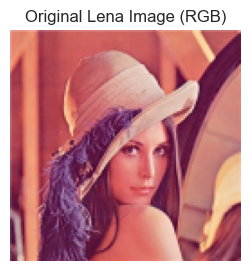

In [9]:
# Display the original image
plt.figure(figsize=(4, 3))
plt.imshow(img_rgb)
plt.title("Original Lena Image (RGB)")
plt.axis("off")
plt.show()

In [10]:
# Convert to HSV color space for thresholding
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

In [11]:
# Print HSV image info
print(f"\n=== Step 2: HSV Conversion Info ===")
print(f"HSV image shape (H × W × Channels): {img_hsv.shape}")
print(f"HSV image data type: {img_hsv.dtype}")  # uint8 (0-255)
print(f"HSV Channel Ranges (OpenCV standards):")
print(f"  Hue (H): [0, 179] (0-360° compressed to 0-179)")
print(f"  Saturation (S): [0, 255]")
print(f"  Value (V): [0, 255]")
print(f"Actual HSV pixel ranges in image:")
print(f"  H: [{img_hsv[:, :, 0].min()}, {img_hsv[:, :, 0].max()}]")
print(f"  S: [{img_hsv[:, :, 1].min()}, {img_hsv[:, :, 1].max()}]")
print(f"  V: [{img_hsv[:, :, 2].min()}, {img_hsv[:, :, 2].max()}]")


=== Step 2: HSV Conversion Info ===
HSV image shape (H × W × Channels): (128, 128, 3)
HSV image data type: float32
HSV Channel Ranges (OpenCV standards):
  Hue (H): [0, 179] (0-360° compressed to 0-179)
  Saturation (S): [0, 255]
  Value (V): [0, 255]
Actual HSV pixel ranges in image:
  H: [0.0, 360.0]
  S: [0.12189855426549911, 0.9662916660308838]
  V: [0.25882354378700256, 1.0]


In [12]:
# %%
print("\nConverted image to HSV color space for better color segmentation")


Converted image to HSV color space for better color segmentation


# <a id='toc4_'></a>[Step 3: Understand HSV Ranges for Common Colors](#toc0_)
Let's define typical HSV ranges for colors we might want to segment in the Lena image.

In [13]:
# Define HSV ranges for common colors (in OpenCV's range: H[0-179], S[0-255], V[0-255])
color_ranges = {
    'skin': {
        'lower': np.array([0, 20, 70]),    # Lower bound for skin tones
        'upper': np.array([20, 255, 255])  # Upper bound for skin tones
    },
    'hair': {
        'lower': np.array([0, 0, 0]),      # low-moderate saturation
        'upper': np.array([179, 180, 120])  # wider dark brightness range
    },
    'red': {
        'lower': np.array([0, 120, 70]),   # Lower bound for red (education use)
        'upper': np.array([10, 255, 255])  # Upper bound for red
    },
    'blue': {
        'lower': np.array([100, 120, 70]), # Lower bound for blue (education use)
        'upper': np.array([130, 255, 255]) # Upper bound for blue
    }
}

In [14]:
# Print the ranges for reference (enhanced with channel labels)
print("\n=== Step 3: HSV Color Ranges for Segmentation ===")
for color, ranges in color_ranges.items():
    lower_h, lower_s, lower_v = ranges['lower']
    upper_h, upper_s, upper_v = ranges['upper']
    print(f"\n{color.upper()}:")
    print(f"  Hue (H): [{lower_h}, {upper_h}] (° scaled to 0-179)")
    print(f"  Saturation (S): [{lower_s}, {upper_s}] (0-255)")
    print(f"  Value (V): [{lower_v}, {upper_v}] (0-255)")


=== Step 3: HSV Color Ranges for Segmentation ===

SKIN:
  Hue (H): [0, 20] (° scaled to 0-179)
  Saturation (S): [20, 255] (0-255)
  Value (V): [70, 255] (0-255)

HAIR:
  Hue (H): [0, 179] (° scaled to 0-179)
  Saturation (S): [0, 180] (0-255)
  Value (V): [0, 120] (0-255)

RED:
  Hue (H): [0, 10] (° scaled to 0-179)
  Saturation (S): [120, 255] (0-255)
  Value (V): [70, 255] (0-255)

BLUE:
  Hue (H): [100, 130] (° scaled to 0-179)
  Saturation (S): [120, 255] (0-255)
  Value (V): [70, 255] (0-255)


# <a id='toc5_'></a>[Step 4: Perform Color Thresholding and Segmentation](#toc0_)
We'll create masks for different colors and apply them to isolate regions in the image.

In [15]:
def segment_color(color_name):
    """
    Segment a specific color from the image using HSV thresholding.
    
    Parameters:
    color_name: Name of color to segment (from color_ranges)
    """
    # Get the HSV range for the specified color
    lower = color_ranges[color_name]['lower']
    upper = color_ranges[color_name]['upper']
    
    # Create a mask where pixels fall within the HSV range
    mask = cv2.inRange(img_hsv, lower, upper)
    
    # Apply the mask to the original image (use uint8 version for consistency)
    segmented = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    segmented_rgb = cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)  # Convert back to RGB for plt.imshow
    
    # NEW: Print mask and segmented image info
    print(f"\n=== Step 4: {color_name.capitalize()} Segmentation Info ===")
    print(f"Mask shape (H × W): {mask.shape}")
    print(f"Mask data type: {mask.dtype} (0 = non-target, 255 = target)")
    target_pixels = np.count_nonzero(mask)  # Pixels matching the color range
    total_pixels = mask.shape[0] * mask.shape[1]
    print(f"Target ({color_name}) pixels: {target_pixels} ({target_pixels/total_pixels*100:.1f}% of image)")
    
    # Display results
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(f"{color_name.capitalize()} Mask")
    axes[1].axis("off")
    
    axes[2].imshow(segmented_rgb)
    axes[2].set_title(f"Segmented {color_name.capitalize()} Regions")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    return mask

Segmenting skin tones...

=== Step 4: Skin Segmentation Info ===
Mask shape (H × W): (128, 128)
Mask data type: uint8 (0 = non-target, 255 = target)
Target (skin) pixels: 0 (0.0% of image)


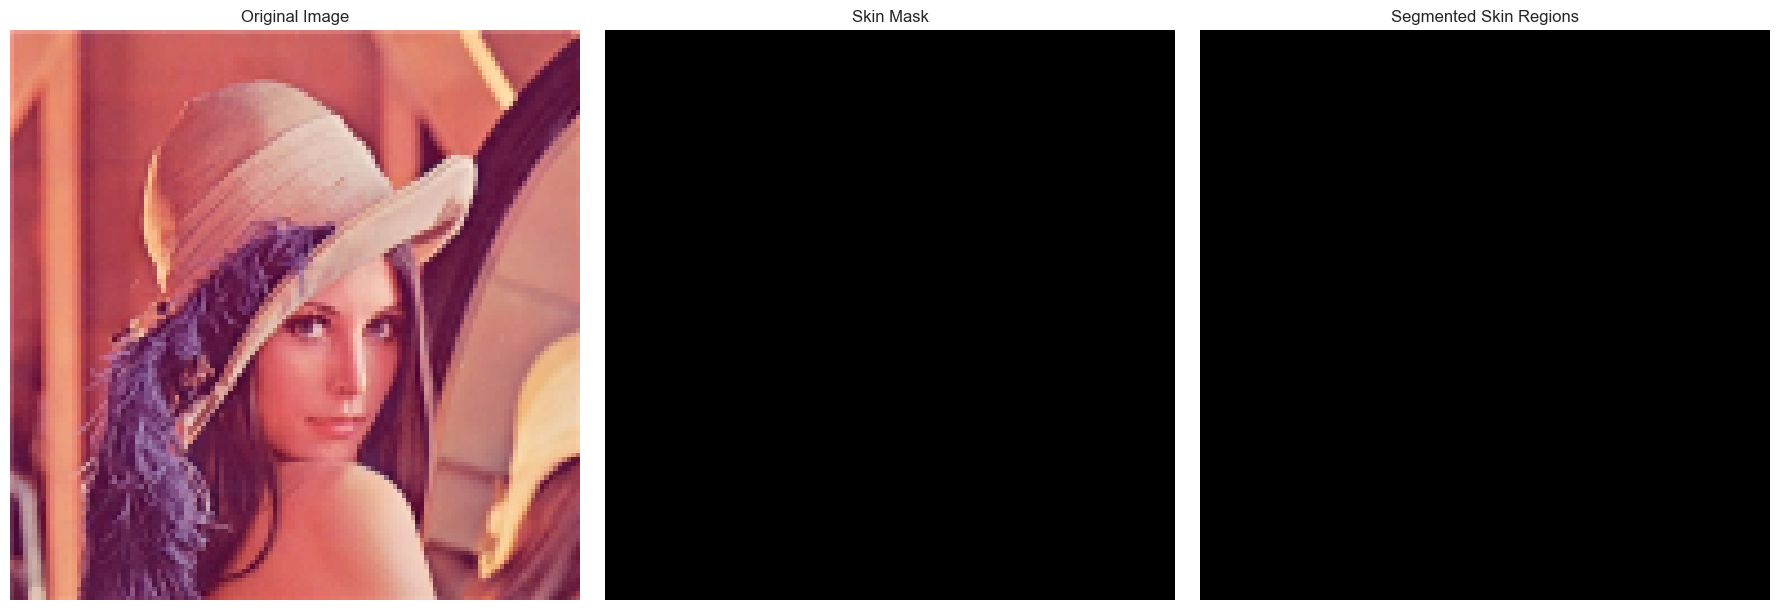

In [16]:
# Segment skin tones
print("Segmenting skin tones...")
skin_mask = segment_color('skin')


Segmenting dark hair...

=== Step 4: Hair Segmentation Info ===
Mask shape (H × W): (128, 128)
Mask data type: uint8 (0 = non-target, 255 = target)
Target (hair) pixels: 7278 (44.4% of image)


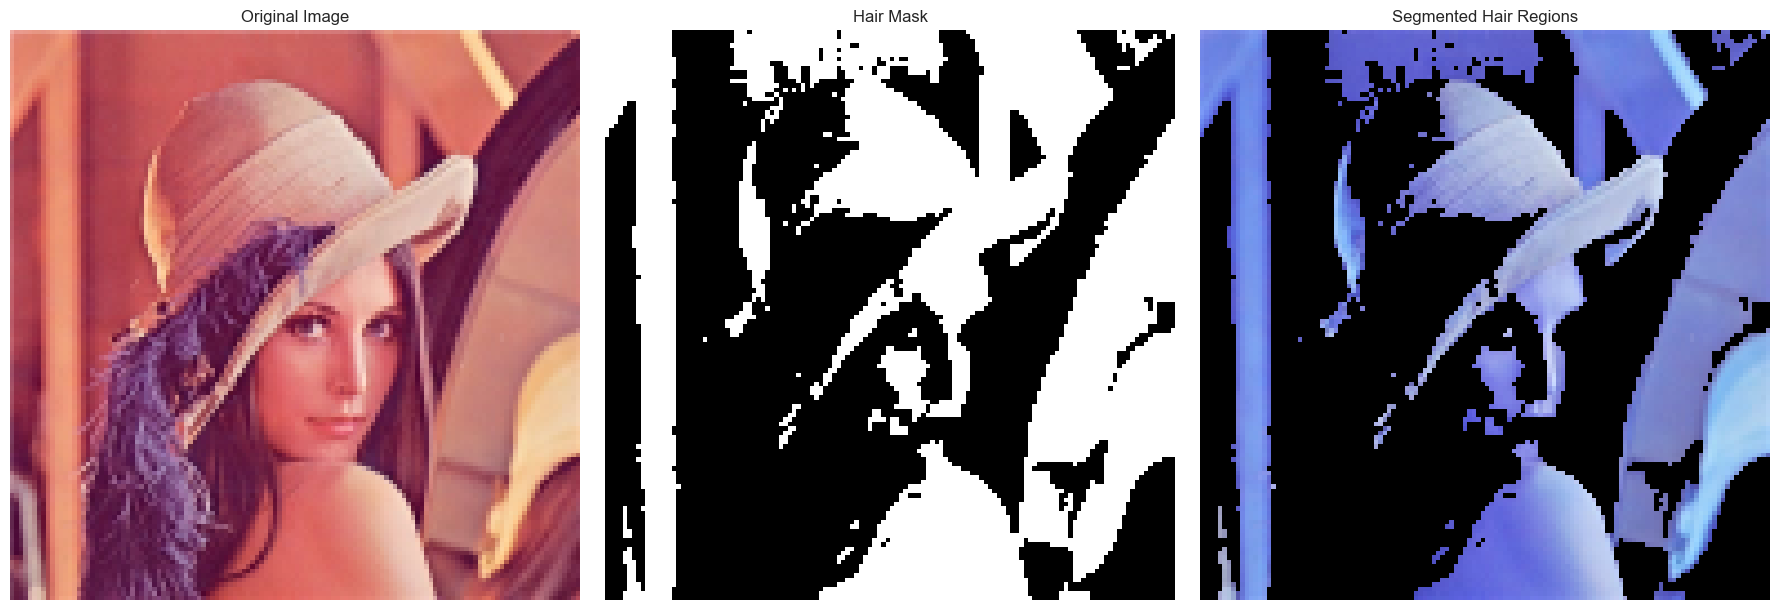

In [17]:
# Segment dark hair
print("\nSegmenting dark hair...")
hair_mask = segment_color('hair')

# <a id='toc6_'></a>[Step 5: Combine Masks for Complex Segmentation](#toc0_)
We can combine multiple masks to isolate more complex regions.

In [18]:
# Combine skin and hair masks
combined_mask = cv2.bitwise_or(skin_mask, hair_mask)

In [19]:
# Print combined mask info
print(f"\n=== Step 5: Combined Mask Info ===")
print(f"Combined mask shape (H × W): {combined_mask.shape}")
combined_pixels = np.count_nonzero(combined_mask)
total_pixels = combined_mask.shape[0] * combined_mask.shape[1]
overlap_pixels = np.count_nonzero(cv2.bitwise_and(skin_mask, hair_mask))  # Pixels in both skin and hair masks
print(f"Combined (skin + hair) pixels: {combined_pixels} ({combined_pixels/total_pixels*100:.1f}% of image)")
print(f"Overlapping pixels (skin ∩ hair): {overlap_pixels} (avoids double-counting)")



=== Step 5: Combined Mask Info ===
Combined mask shape (H × W): (128, 128)
Combined (skin + hair) pixels: 7278 (44.4% of image)
Overlapping pixels (skin ∩ hair): 0 (avoids double-counting)


In [20]:
# Apply the combined mask
combined_segmented = cv2.bitwise_and(img_rgb, img_rgb, mask=combined_mask)

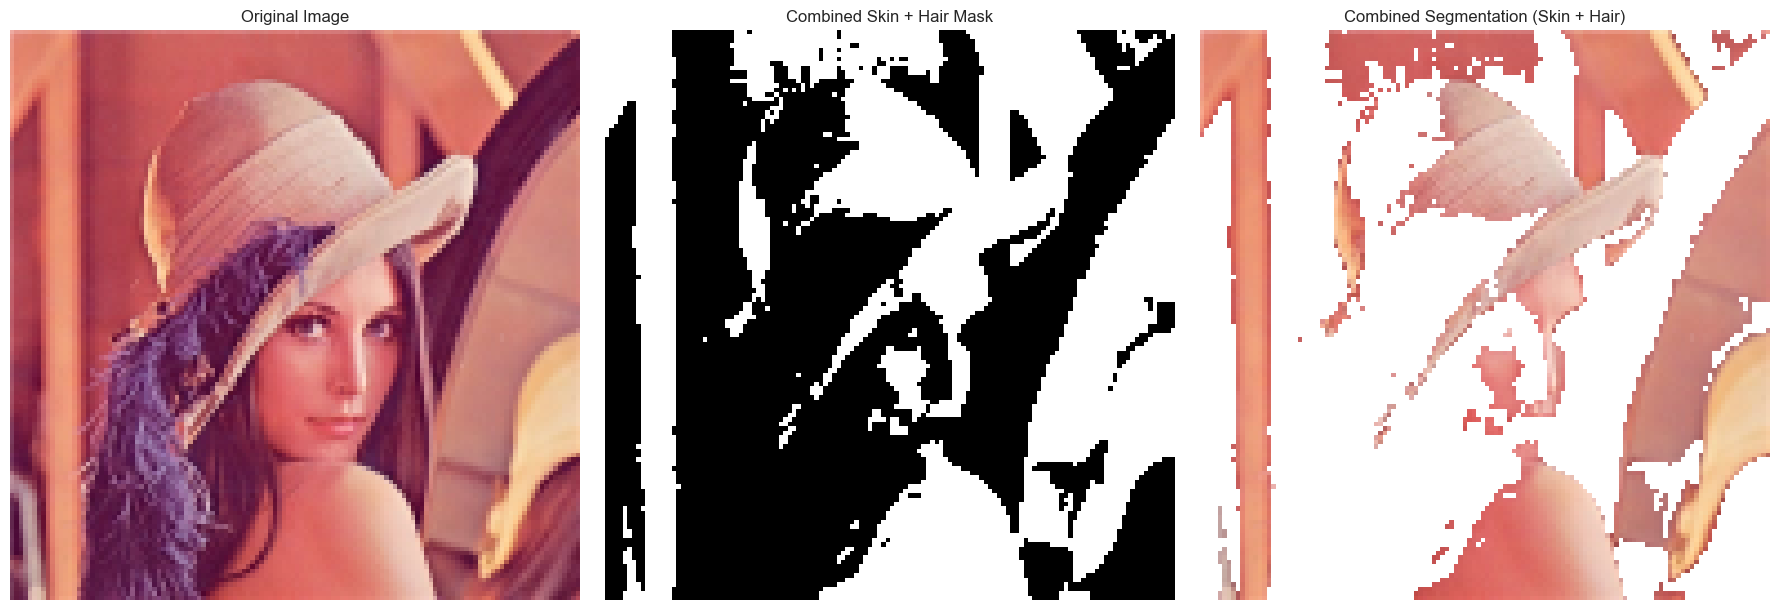

In [21]:
# Display results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(combined_mask, cmap='gray')
axes[1].set_title("Combined Skin + Hair Mask")
axes[1].axis("off")

axes[2].imshow(combined_segmented)
axes[2].set_title("Combined Segmentation (Skin + Hair)")
axes[2].set_xlabel("Notice how we've isolated the main facial features!")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# <a id='toc7_'></a>[Step 6: Detailed Segmentation Analysis](#toc0_)

Comprehensive metrics for skin and hair segmentation, including pixel counts, percentages, and spatial relationships.

In [22]:
# Calculate core metrics
skin_pixels = np.count_nonzero(skin_mask)          # Number of skin pixels (non-zero values in skin mask)
hair_pixels = np.count_nonzero(hair_mask)          # Number of hair pixels (non-zero values in hair mask)
total_pixels = img_rgb.shape[0] * img_rgb.shape[1] # Total pixels in image (height × width)

In [23]:
# Calculate overlap metrics
overlap_pixels = np.count_nonzero(cv2.bitwise_and(skin_mask, hair_mask))  # Pixels in both masks
union_pixels = np.count_nonzero(cv2.bitwise_or(skin_mask, hair_mask))     # Pixels in either mask

In [24]:
# Calculate derived metrics
skin_percent = (skin_pixels / total_pixels) * 100  

$$\left(\frac{Skin Pixels}{Total Pixels}\right) × 100$$
Use `\left` and `\right` before the `bracket` characters to make them autosize

In [25]:
hair_percent = (hair_pixels / total_pixels) * 100

$$\left(\frac{Hair Pixels}{Total Pixels}\right) × 100$$

In [26]:
skin_to_hair_ratio = skin_pixels / hair_pixels if hair_pixels > 0 else 0  

$$Ratio = \frac{Skin Pixels}{Hair Pixels}$$

In [27]:
# Calculate Intersection over Union (IoU) for overlap assessment
# IoU = (Intersection Pixels) ÷ (Union Pixels)
iou = overlap_pixels / union_pixels if union_pixels > 0 else 0

$$IoU = \frac{Intersection Pixels}{Union Pixels}$$

In [28]:
# Calculate overlap percentages relative to each segment
# (Overlap Pixels ÷ Segment Pixels) × 100
skin_overlap_percent = (overlap_pixels / skin_pixels) * 100 if skin_pixels > 0 else 0
hair_overlap_percent = (overlap_pixels / hair_pixels) * 100 if hair_pixels > 0 else 0

$$Overlap Percent = \frac{Overlap Pixels}{Segment Pixels} × 100$$

In [29]:
# Display comprehensive results
print(f"=== Detailed Segmentation Analysis ===")
print(f"Image Dimensions: {img_rgb.shape[0]}px × {img_rgb.shape[1]}px")
print(f"Total Pixels: {total_pixels:,}")

=== Detailed Segmentation Analysis ===
Image Dimensions: 128px × 128px
Total Pixels: 16,384


In [30]:
print("\n--- Absolute Pixel Counts ---")
print(f"Skin Pixels: {skin_pixels:,}")
print(f"Hair Pixels: {hair_pixels:,}")
print(f"Overlapping Pixels (Skin ∩ Hair): {overlap_pixels:,}")
print(f"Union Pixels (Skin ∪ Hair): {union_pixels:,}")


--- Absolute Pixel Counts ---
Skin Pixels: 0
Hair Pixels: 7,278
Overlapping Pixels (Skin ∩ Hair): 0
Union Pixels (Skin ∪ Hair): 7,278


In [31]:
print("\n--- Percentage of Total Image ---")
print(f"Skin: {skin_percent:.1f}% (Formula: (Skin Pixels ÷ Total Pixels) × 100)")
print(f"Hair: {hair_percent:.1f}% (Formula: (Hair Pixels ÷ Total Pixels) × 100)")
print(f"Combined (Skin + Hair): {union_pixels/total_pixels*100:.1f}%")


--- Percentage of Total Image ---
Skin: 0.0% (Formula: (Skin Pixels ÷ Total Pixels) × 100)
Hair: 44.4% (Formula: (Hair Pixels ÷ Total Pixels) × 100)
Combined (Skin + Hair): 44.4%


In [32]:
print("\n--- Relative Relationships ---")
print(f"Skin-to-Hair Ratio: {skin_to_hair_ratio:.2f}:1 (Formula: Skin Pixels ÷ Hair Pixels)")
print(f"Intersection over Union (IoU): {iou:.3f} (Formula: Overlap ÷ Union)")
print(f"Overlap as % of Skin: {skin_overlap_percent:.1f}%")
print(f"Overlap as % of Hair: {hair_overlap_percent:.1f}%")


--- Relative Relationships ---
Skin-to-Hair Ratio: 0.00:1 (Formula: Skin Pixels ÷ Hair Pixels)
Intersection over Union (IoU): 0.000 (Formula: Overlap ÷ Union)
Overlap as % of Skin: 0.0%
Overlap as % of Hair: 0.0%


In [33]:
# Visualize the distribution with a pie chart
# Prepare data for visualization
labels = ['Skin Only', 'Hair Only', 'Both Skin & Hair', 'Background']
sizes = [
    skin_pixels - overlap_pixels,  # Skin only
    hair_pixels - overlap_pixels,  # Hair only
    overlap_pixels,                # Both
    total_pixels - union_pixels    # Background
]

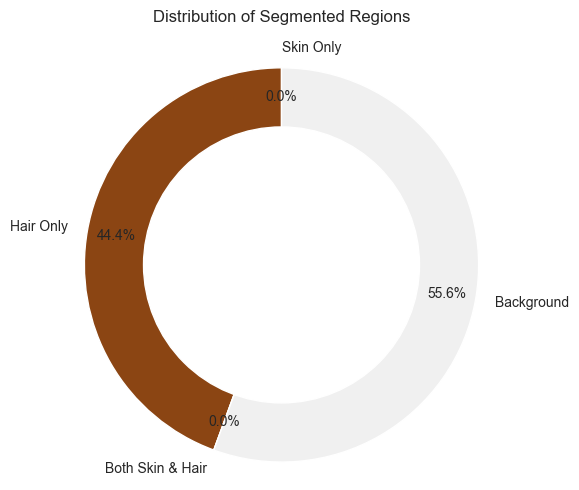

In [34]:
# Create pie chart
plt.figure(figsize=(6, 5))
colors = ['#FFD1DC', '#8B4513', '#FFA07A', '#F0F0F0']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, pctdistance=0.85)

# Draw circle for donut effect
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Segmented Regions', pad=20)
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle
plt.tight_layout()
plt.show()

# <a id='toc8_'></a>[Step 7: Adjust Thresholds Interactively](#toc0_)
* For better results, we can fine-tune the HSV ranges using interactive sliders.
* `ipywidgets` is an abbreviation for `Interactive Python Widgets`.

In [35]:
# ipywidgets as a toolkit for building interactive controls 
# (like sliders, buttons, or dropdowns) directly in Jupyter notebooks. 
# It lets you add "user interface" elements to your code, 
# making it easy to tweak parameters and see results in real time.
import ipywidgets as widgets

In [36]:
# interact is a shortcut function from ipywidgets 
# that automatically creates interactive controls (like sliders) 
# for your functions. 

# It connects your function’s input parameters to these controls, 
# so changing a slider (for example) instantly re-runs the function with the new value.
from ipywidgets import interact

In [37]:
def adjust_thresholds(h_min, h_max, s_min, s_max, v_min, v_max):
    """Interactive function to adjust HSV thresholds - now includes original image"""
    lower = np.array([h_min, s_min, v_min])
    upper = np.array([h_max, s_max, v_max])
    
    mask = cv2.inRange(img_hsv, lower, upper)
 
    segmented = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    
    # Create a figure with 3 subplots: Original, Mask, Segmented
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # Original image
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    # Mask
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Mask")
    axes[1].axis("off")
    
    # Segmented image
    axes[2].imshow(segmented)
    axes[2].set_title("Segmented Image")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

In [38]:
print("Use the sliders below to adjust HSV thresholds \n(try segmenting different features!):")

Use the sliders below to adjust HSV thresholds 
(try segmenting different features!):


In [39]:
interact(adjust_thresholds,
            h_min=widgets.IntSlider(min=0, max=179, value=0),
            h_max=widgets.IntSlider(min=0, max=179, value=179),
            s_min=widgets.IntSlider(min=0, max=255, value=0),
            s_max=widgets.IntSlider(min=0, max=255, value=255),
            v_min=widgets.IntSlider(min=0, max=255, value=0),
            v_max=widgets.IntSlider(min=0, max=255, value=255));

interactive(children=(IntSlider(value=0, description='h_min', max=179), IntSlider(value=179, description='h_ma…